In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

DATASET_DIR = "/content/drive/MyDrive/Mammogram_Project"

OUTPUT_DIR = "/content/drive/MyDrive/Mammogram_Shape_Preprocess"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset Directory :", DATASET_DIR)
print("Output Directory  :", OUTPUT_DIR)

print("\nFiles in dataset folder:")
print(os.listdir(DATASET_DIR))

Dataset Directory : /content/drive/MyDrive/Mammogram_Project
Output Directory  : /content/drive/MyDrive/Mammogram_Shape_Preprocess

Files in dataset folder:
['mass_case_description_train_set.csv', 'calc_case_description_train_set.csv', 'meta.csv', 'mass_case_description_test_set.csv', 'dicom_info.csv', 'calc_case_description_test_set.csv', 'X.npy', 'Y.npy', 'ROI_Y.npy', 'ROI_X.npy', 'NEW_ROI_X.npy', 'NEW_ROI_Y.npy', 'jpeg', 'density_x.npy', 'density_y.npy', 'density_labels.npy', 'density_roi_images', 'density_roi_masks', 'Density_ROI_Dataset']


In [4]:
import glob

csv_files = glob.glob(
    os.path.join(DATASET_DIR, "*.csv")
)

print(f"Found {len(csv_files)} CSV files:\n")

for file in csv_files:
    print(os.path.basename(file))

Found 6 CSV files:

mass_case_description_train_set.csv
calc_case_description_train_set.csv
meta.csv
mass_case_description_test_set.csv
dicom_info.csv
calc_case_description_test_set.csv


In [5]:
dfs = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {os.path.basename(file)}")
        print(e)

data = pd.concat(dfs, ignore_index=True)

print(f"Total rows: {len(data)}")
data.head()

Total rows: 20580


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,...,SOPClassUID,SOPInstanceUID,SamplesPerPixel,SecondaryCaptureDeviceManufacturer,SecondaryCaptureDeviceManufacturerModelName,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyTime
0,P_00001,3.0,LEFT,CC,1.0,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4.0,MALIGNANT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P_00001,3.0,LEFT,MLO,1.0,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4.0,MALIGNANT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P_00004,3.0,LEFT,CC,1.0,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P_00004,3.0,LEFT,MLO,1.0,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P_00004,3.0,RIGHT,MLO,1.0,mass,OVAL,CIRCUMSCRIBED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Pathology")
display(data["pathology"].value_counts())

print("\nAbnormality Type")
display(data["abnormality type"].value_counts())

print("\nMass Shape")
display(data["mass shape"].value_counts())

Pathology


,count
pathology,
MALIGNANT,1457
BENIGN,1429
BENIGN_WITHOUT_CALLBACK,682



Abnormality Type


,count
abnormality type,
calcification,1872
mass,1696



Mass Shape


,count
mass shape,
IRREGULAR,464
OVAL,412
LOBULATED,384
ROUND,164
ARCHITECTURAL_DISTORTION,103
IRREGULAR-ARCHITECTURAL_DISTORTION,52
LYMPH_NODE,35
FOCAL_ASYMMETRIC_DENSITY,25
ASYMMETRIC_BREAST_TISSUE,25


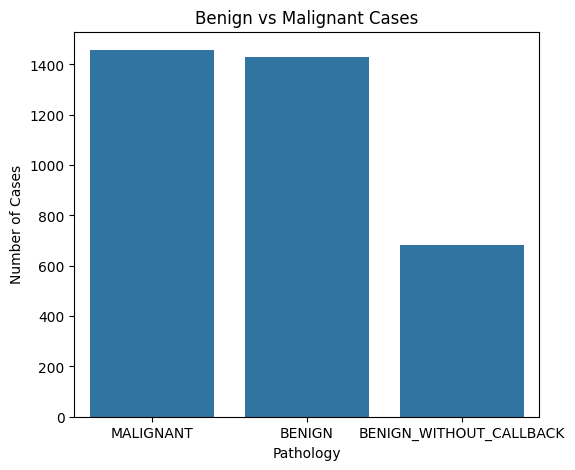

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.countplot(x='pathology', data=data)

plt.title('Benign vs Malignant Cases')
plt.xlabel('Pathology')
plt.ylabel('Number of Cases')
plt.show()

In [8]:
VALID_SHAPES = [
    "IRREGULAR",
    "OVAL",
    "LOBULATED"
]

data = data[
    (data["abnormality type"] == "mass") &
    (data["mass shape"].isin(VALID_SHAPES))
].reset_index(drop=True)

print("Total Mass Cases:", len(data))

print("\nMass Shape Distribution")
display(data["mass shape"].value_counts())

Total Mass Cases: 1260

Mass Shape Distribution


,count
mass shape,
IRREGULAR,464
OVAL,412
LOBULATED,384


In [9]:
print("Filtered Dataset Summary")

print("Patients :", data["patient_id"].nunique())
print("Images   :", len(data))

print("\nMass Shapes")

display(data["mass shape"].value_counts())

print("\nPathology")

display(data["pathology"].value_counts())

Filtered Dataset Summary
Patients : 713
Images   : 1260

Mass Shapes


,count
mass shape,
IRREGULAR,464
OVAL,412
LOBULATED,384



Pathology


,count
pathology,
BENIGN,613
MALIGNANT,601
BENIGN_WITHOUT_CALLBACK,46


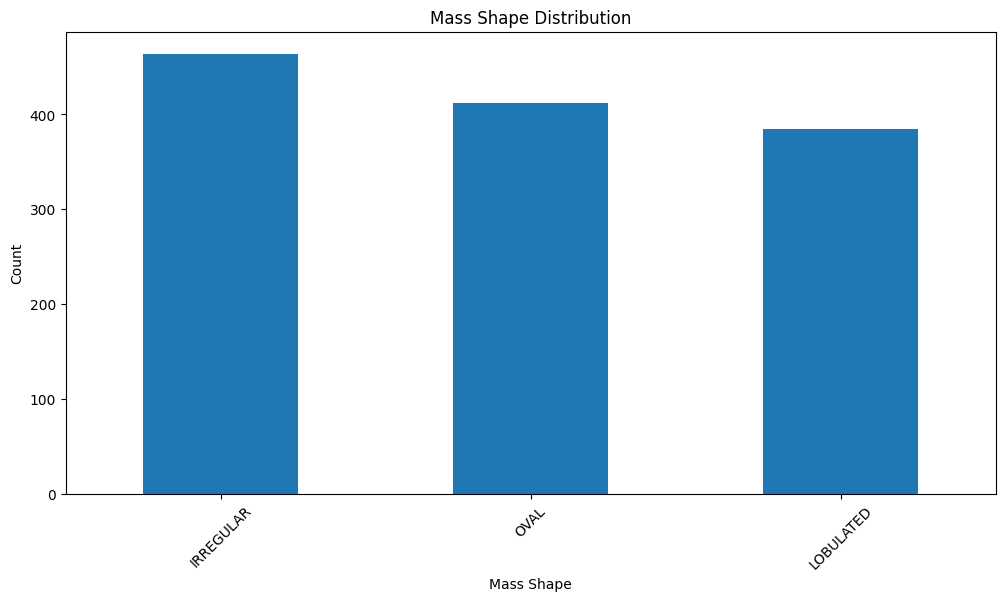

In [10]:
plt.figure(figsize=(12,6))

data['mass shape'].value_counts().plot(
    kind='bar'
)

plt.title('Mass Shape Distribution')
plt.xlabel('Mass Shape')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [11]:
dicom_csv = os.path.join(DATASET_DIR, "dicom_info.csv")
df = pd.read_csv(dicom_csv)
print(df.shape)
df.head()

(10237, 38)


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [12]:
df['SeriesDescription'].value_counts()

,count
SeriesDescription,
cropped images,3567
ROI mask images,3247
full mammogram images,2857


In [17]:
import os

df["full_path"] = df["image_path"].str.replace(
    "CBIS-DDSM/jpeg",
    os.path.join(DATASET_DIR, "jpeg"),
    regex=False
)

df["exists"] = df["full_path"].apply(os.path.exists)

print(df["exists"].value_counts())

exists
True    9671
Name: count, dtype: int64


In [18]:
df = df.dropna(subset=['SeriesDescription']).copy()

In [19]:
mammo_df = df[df["SeriesDescription"] == "full mammogram images"].copy()
mask_df = df[df["SeriesDescription"] == "ROI mask images"].copy()
crop_df = df[df["SeriesDescription"] == "cropped images"].copy()

print("Full Mammograms :", len(mammo_df))
print("ROI Masks       :", len(mask_df))
print("Cropped Images  :", len(crop_df))

Full Mammograms : 2857
ROI Masks       : 3247
Cropped Images  : 3567


In [20]:
mammo_dict = {}

for _, row in mammo_df.iterrows():
    mammo_dict[row['PatientID']] = row['full_path']

In [21]:
# Create lookup dictionaries
shape_lookup = {}
patient_lookup = {}

for _, row in data.iterrows():

    roi_folder = row["ROI mask file path"].split("/")[0]

    shape_lookup[roi_folder] = row["mass shape"]
    patient_lookup[roi_folder] = row["patient_id"]


pairs = []
patient_ids = []

# Build image-mask-shape pairs
for _, row in mask_df.iterrows():

    mask_id = row["PatientID"]
    mask_path = row["full_path"]

    # Convert "P_00001_LEFT_CC_1" -> "P_00001_LEFT_CC"
    base_id = mask_id.rsplit("_", 1)[0]

    # Skip if corresponding mammogram doesn't exist
    if base_id not in mammo_dict:
        continue

    # Skip if no shape label exists
    if mask_id not in shape_lookup:
        continue

    pairs.append((
        mammo_dict[base_id],
        mask_path,
        shape_lookup[mask_id]
    ))

    patient_ids.append(patient_lookup[mask_id])


print(f"Total matched pairs      : {len(pairs)}")
print(f"Total patient IDs        : {len(patient_ids)}")
print(f"Unique patients          : {len(set(patient_ids))}")

# Sanity check
assert len(pairs) == len(patient_ids), "Mismatch between pairs and patient IDs!"

Total matched pairs      : 1260
Total patient IDs        : 1260
Unique patients          : 713


In [22]:
for i in range(min(5, len(pairs))):
    img, mask, shape = pairs[i]

    print("Shape :", shape)
    print("Image :", img)
    print("Mask  :", mask)
    print("-"*80)

Shape : LOBULATED
Image : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.330740809913644315209371578112284206839/1-146.jpg
Mask  : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.jpg
--------------------------------------------------------------------------------
Shape : LOBULATED
Image : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.156666634411136072728329168882908966996/1-288.jpg
Mask  : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.231894579813593468217419823840305212127/2-279.jpg
--------------------------------------------------------------------------------
Shape : IRREGULAR
Image : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.256330807412877366440153727190246662818/1-055.jpg
Mask  : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.286212602510327696024825204783459108873/2-107.jpg
----------

In [23]:
for i in range(min(5, len(pairs))):
    img, mask, shape = pairs[i]
    print("Shape :", shape)
    print(
        "Image PatientID:",
        mammo_df[mammo_df["full_path"] == img]["PatientID"].values
    )
    print(
        "Mask PatientID:",
        mask_df[mask_df["full_path"] == mask]["PatientID"].values
    )
    print("-"*80)

Shape : LOBULATED
Image PatientID: ['Mass-Training_P_00242_RIGHT_CC']
Mask PatientID: ['Mass-Training_P_00242_RIGHT_CC_1']
--------------------------------------------------------------------------------
Shape : LOBULATED
Image PatientID: ['Mass-Test_P_00882_RIGHT_CC']
Mask PatientID: ['Mass-Test_P_00882_RIGHT_CC_1']
--------------------------------------------------------------------------------
Shape : IRREGULAR
Image PatientID: ['Mass-Training_P_00241_RIGHT_CC']
Mask PatientID: ['Mass-Training_P_00241_RIGHT_CC_1']
--------------------------------------------------------------------------------
Shape : OVAL
Image PatientID: ['Mass-Test_P_00381_LEFT_MLO']
Mask PatientID: ['Mass-Test_P_00381_LEFT_MLO_1']
--------------------------------------------------------------------------------
Shape : IRREGULAR
Image PatientID: ['Mass-Training_P_00348_LEFT_MLO']
Mask PatientID: ['Mass-Training_P_00348_LEFT_MLO_1']
--------------------------------------------------------------------------------


In [24]:
meta = pd.read_csv(os.path.join(DATASET_DIR, "meta.csv"))
meta.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


In [25]:
meta['SeriesDescription'].value_counts()

,count
SeriesDescription,
ROI mask images,3565
full mammogram images,3103
cropped images,107


In [26]:
full_meta = meta[
    meta['SeriesDescription'] == 'full mammogram images'
].copy()

mask_meta = meta[
    meta['SeriesDescription'] == 'ROI mask images'
].copy()

crop_meta = meta[
    meta['SeriesDescription'] == 'cropped images'
].copy()

print(len(full_meta))
print(len(mask_meta))
print(len(crop_meta))

3103
3565
107


In [27]:
common = set(full_meta['StudyInstanceUID']) & \
         set(mask_meta['StudyInstanceUID'])

print("Common studies:", len(common))

Common studies: 0


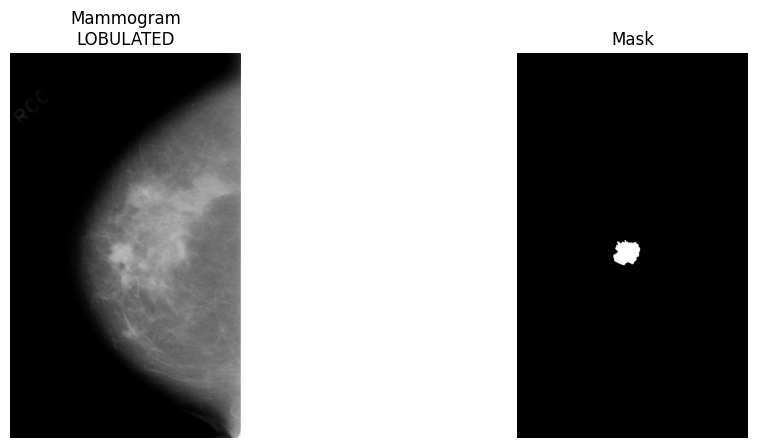

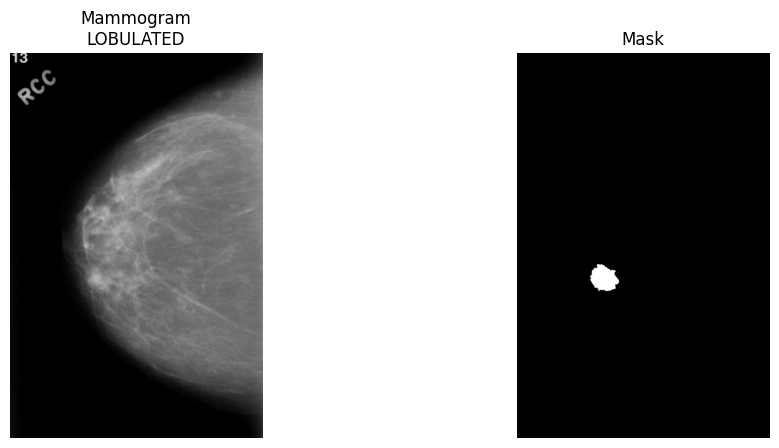

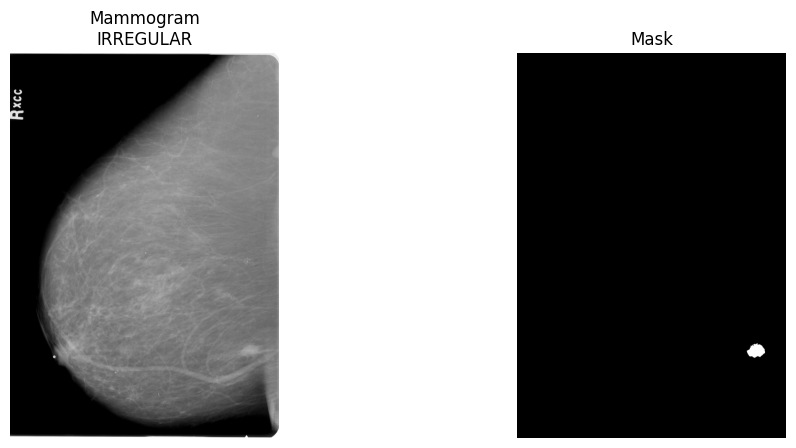

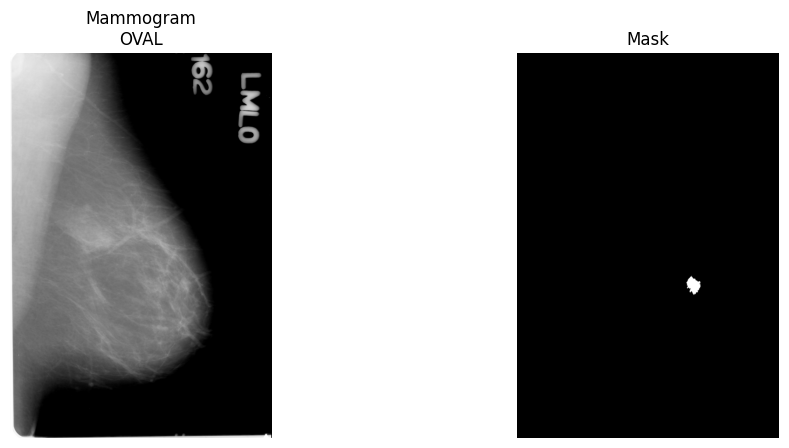

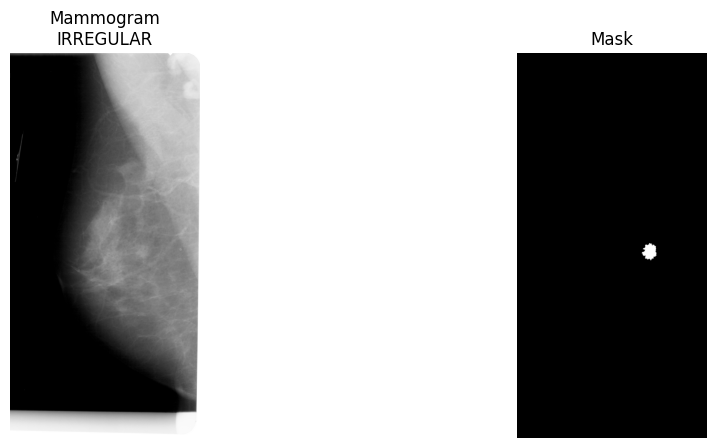

In [28]:
import cv2
import matplotlib.pyplot as plt

for i in range(5):

    img_path, mask_path, shape = pairs[i]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    fig, ax = plt.subplots(1,2, figsize=(12,5))

    ax[0].imshow(img, cmap="gray")
    ax[0].set_title(f"Mammogram\n{shape}")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Mask")
    ax[1].axis("off")

    plt.show()

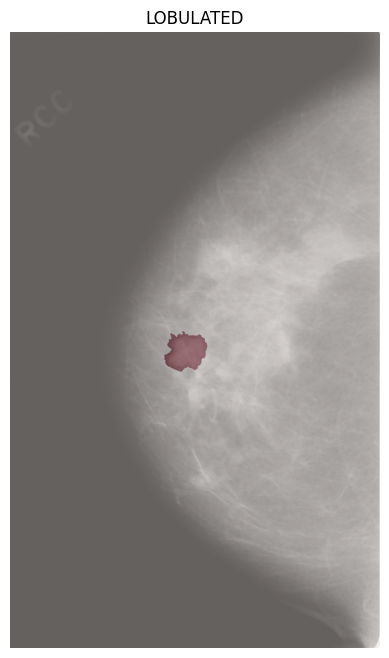

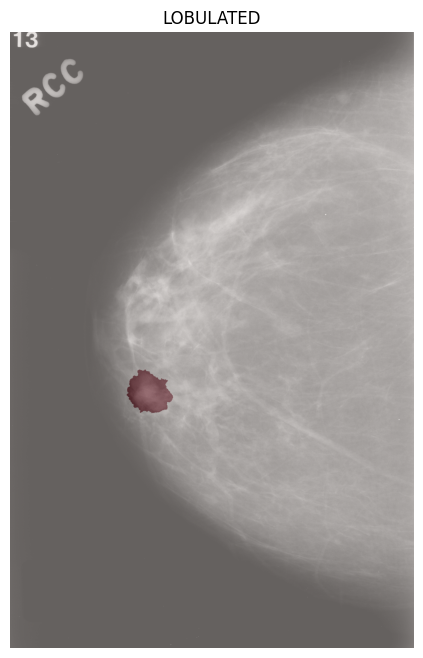

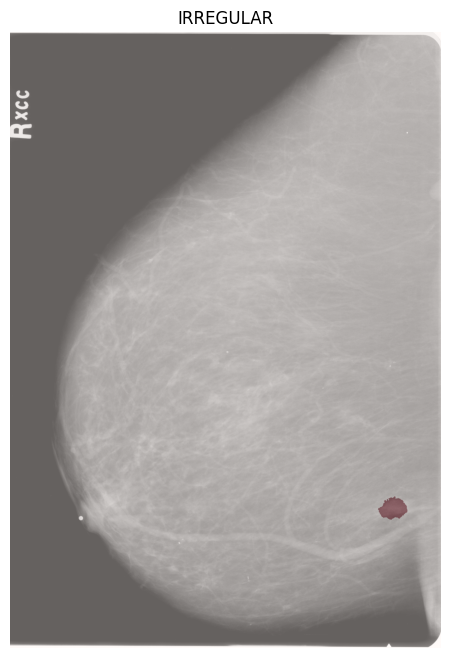

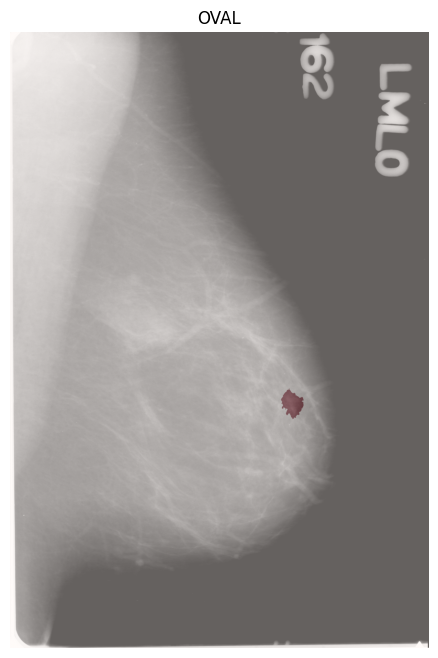

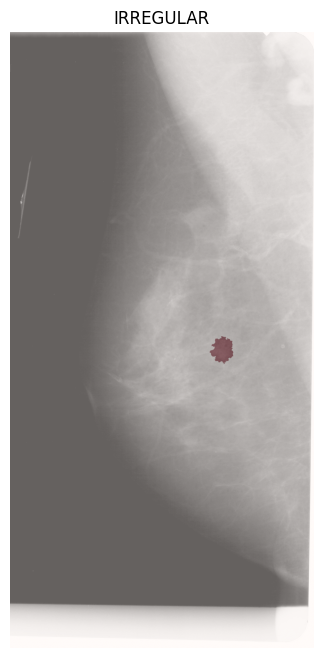

In [29]:
for i in range(5):

    img_path, mask_path, shape = pairs[i]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    mask = cv2.resize(
        mask,
        (img.shape[1], img.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    plt.figure(figsize=(8,8))

    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="Reds", alpha=0.4)

    plt.title(shape)

    plt.axis("off")

    plt.show()

In [30]:
import cv2
import numpy as np

def right_orientation(img):
    """
    Make every mammogram face the same direction.
    If the breast is on the left half, flip horizontally.
    """

    h, w = img.shape

    left_half = img[:, :w//2]
    right_half = img[:, w//2:]

    left_pixels = np.count_nonzero(left_half)
    right_pixels = np.count_nonzero(right_half)

    # Breast on left -> flip
    if left_pixels > right_pixels:
        img = cv2.flip(img, 1)

    return img

In [31]:
import cv2
import numpy as np

def remove_background(img):

    # Create binary image
    _, thresh = cv2.threshold(img, 5, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return img

    # Largest contour = breast region
    largest = max(contours, key=cv2.contourArea)

    # Create mask
    mask = np.zeros_like(img)
    cv2.drawContours(mask, [largest], -1, 255, thickness=-1)

    # Keep only breast
    breast = cv2.bitwise_and(img, img, mask=mask)

    return breast

In [32]:
def preprocess_image(path, resize=True):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Orientation correction
    img = right_orientation(img)

    # Remove background
    img = remove_background(img)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    img = clahe.apply(img)

    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Resize only if requested
    if resize:
        img = cv2.resize(img, (256, 256))

    img = img.astype(np.float32) / 255.0

    return img

In [33]:
# def preprocess_image(path):

#     img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# # Orientation correction
#     img = right_orientation(img)

# # Remove background
#     img = remove_background(img)

#     clahe = cv2.createCLAHE(
#         clipLimit=2.0,
#         tileGridSize=(8,8)
#     )
#     img = clahe.apply(img)

#     img = cv2.GaussianBlur(img, (3,3), 0)

#     img = cv2.resize(img, (256,256))

#     img = img.astype(np.float32) / 255.0

#     return img


import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image_steps(path, resize=True):

    original = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Step 1: Orientation Fix
    orientation = right_orientation(original.copy())

    # Step 2: Background Removal
    background = remove_background(orientation.copy())

    # Step 3: CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
    clahe_img = clahe.apply(background.copy())

    # Step 4: Gaussian Blur
    blur = cv2.GaussianBlur(clahe_img, (3,3), 0)

    # Step 5: Resize
    resized = cv2.resize(blur, (256,256))

    # Step 6: Normalize
    normalized = resized.astype(np.float32) / 255.0

    return {
        "Original": original,
        "Orientation Fix": orientation,
        "Background Removal": background,
        "CLAHE": clahe_img,
        "Blur": blur,
        "Resize (256×256)": resized,
        "Normalize": normalized
    }

In [35]:
import os

os.makedirs("preprocessing_steps", exist_ok=True)

# Call preprocess_image_steps to get the dictionary of steps
steps = preprocess_image_steps(pairs[0][0])

for name, img in steps.items():

    filename = name.replace(" ", "_").replace("(","").replace(")","")

    if img.dtype == np.float32:
        img = (img*255).astype(np.uint8)

    cv2.imwrite(f"preprocessing_steps/{filename}.png", img)

In [36]:
def preprocess_mask(path, resize=True):

    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    mask = right_orientation(mask)

    if resize:
        mask = cv2.resize(
            mask,
            (256, 256),
            interpolation=cv2.INTER_NEAREST
        )

    # Binary mask
    mask = (mask > 0).astype(np.uint8)

    return mask

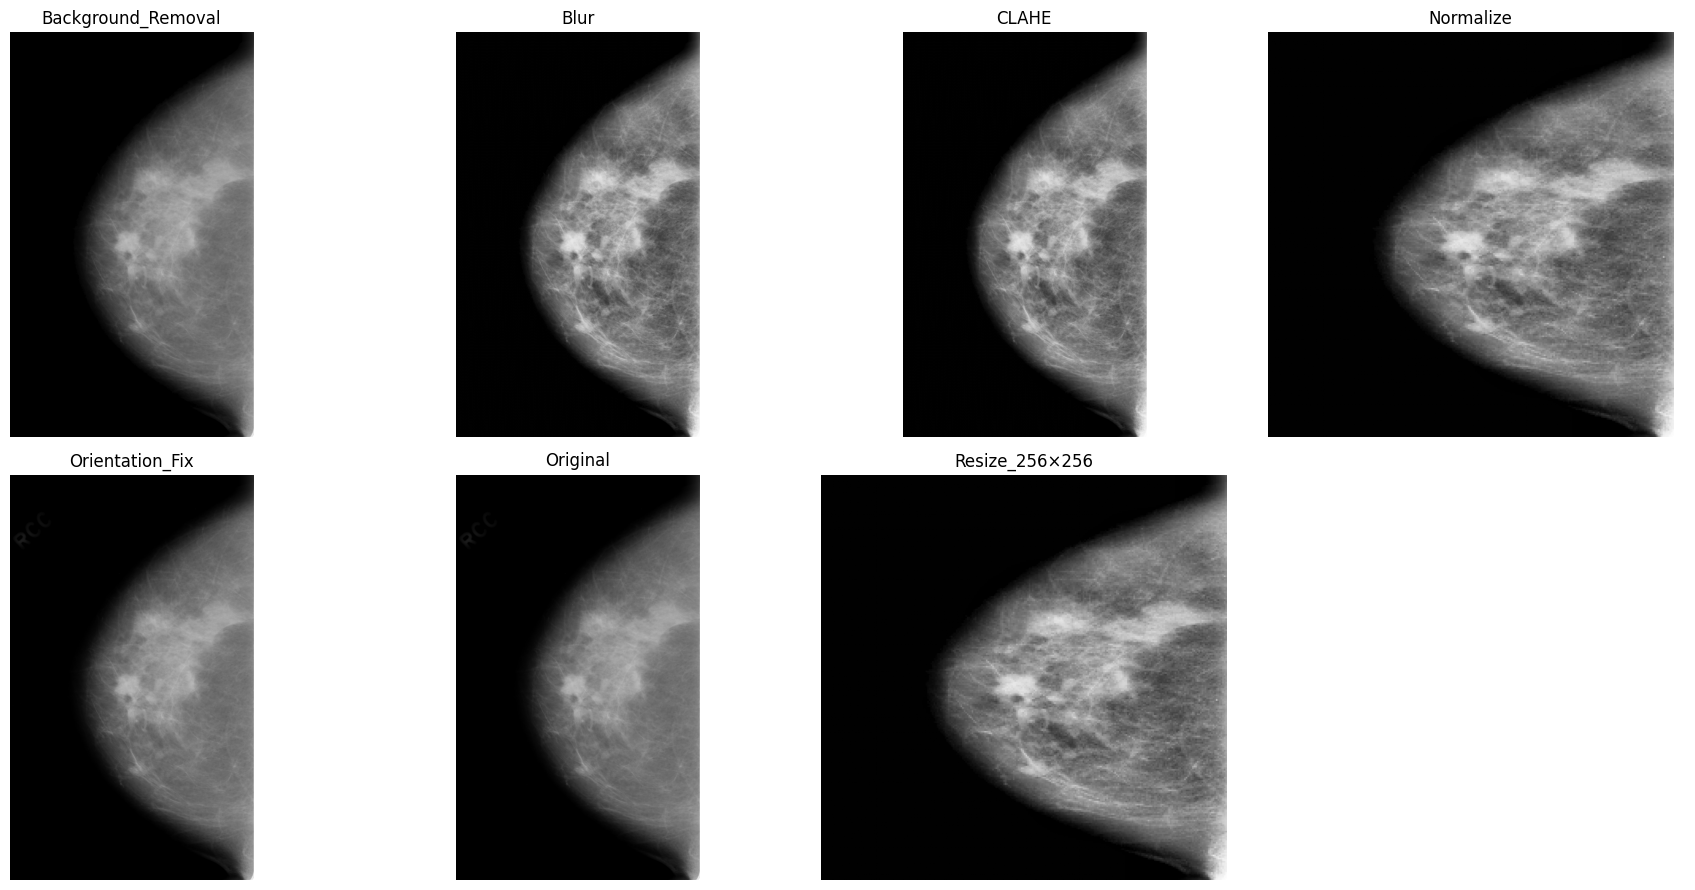

In [37]:
import os
import cv2
import matplotlib.pyplot as plt

folder = "preprocessing_steps"

files = sorted(os.listdir(folder))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, file in zip(axes, files):
    img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(file.replace(".png",""))
    ax.axis('off')

# Hide unused subplots
for i in range(len(files), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [39]:
import time

shape_to_label = {
    "IRREGULAR": 0,
    "OVAL": 1,
    "LOBULATED": 2
}

X = []
Y = []
shape_labels = []
valid_patient_ids = []

start = time.time()

for i, ((img_path, mask_path, shape), pid) in enumerate(zip(pairs, patient_ids)):

    try:
        X.append(preprocess_image(img_path))
        Y.append(preprocess_mask(mask_path))
        shape_labels.append(shape_to_label[shape])
        valid_patient_ids.append(pid)

    except Exception as e:
        print(f"Skipped sample {i}: {img_path}")
        print(e)
        continue

    if (i + 1) % 50 == 0:
        print(f"{i+1}/{len(pairs)} processed ({time.time()-start:.1f} sec)")

# Keep patient IDs synchronized with X, Y and labels
patient_ids = valid_patient_ids

print("\nPreprocessing completed!")
print(f"Images processed : {len(X)}")
print(f"Masks processed  : {len(Y)}")
print(f"Labels processed : {len(shape_labels)}")

50/1260 processed (37.6 sec)
100/1260 processed (73.2 sec)
150/1260 processed (108.3 sec)
200/1260 processed (143.4 sec)
250/1260 processed (178.8 sec)
300/1260 processed (215.4 sec)
350/1260 processed (251.0 sec)
400/1260 processed (287.1 sec)
450/1260 processed (338.1 sec)
500/1260 processed (402.3 sec)
550/1260 processed (465.9 sec)
600/1260 processed (528.4 sec)
650/1260 processed (592.4 sec)
700/1260 processed (654.1 sec)
750/1260 processed (716.1 sec)
800/1260 processed (780.8 sec)
850/1260 processed (842.4 sec)
900/1260 processed (910.4 sec)
950/1260 processed (974.8 sec)
1000/1260 processed (1044.8 sec)
1050/1260 processed (1117.3 sec)
1100/1260 processed (1183.6 sec)
1150/1260 processed (1248.0 sec)
1200/1260 processed (1311.6 sec)
1250/1260 processed (1374.6 sec)

Preprocessing completed!
Images processed : 1260
Masks processed  : 1260
Labels processed : 1260


In [40]:
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.uint8)
shape_labels = np.array(shape_labels, dtype=np.int64)

X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Shape labels:", shape_labels.shape)

X shape: (1260, 256, 256, 1)
Y shape: (1260, 256, 256, 1)
Shape labels: (1260,)


In [42]:
# import os
# import cv2

# processed_img_dir = os.path.join(OUTPUT_DIR, "processed_images")
# processed_mask_dir = os.path.join(OUTPUT_DIR, "processed_masks")

# os.makedirs(processed_img_dir, exist_ok=True)
# os.makedirs(processed_mask_dir, exist_ok=True)

# for i, (img_path, mask_path, shape) in enumerate(pairs):

#     img = preprocess_image(img_path)
#     mask = preprocess_mask(mask_path)

#     cv2.imwrite(
#         os.path.join(processed_img_dir, f"img_{i:04d}.png"),
#         (img * 255).astype("uint8")
#     )

#     cv2.imwrite(
#         os.path.join(processed_mask_dir, f"mask_{i:04d}.png"),
#         (mask * 255).astype("uint8")
#     )

In [43]:
import cv2

img = cv2.imread(pairs[0][0], cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(pairs[0][1], cv2.IMREAD_GRAYSCALE)

print(img is None)
print(mask is None)

print(img.shape if img is not None else None)
print(mask.shape if mask is not None else None)

False
False
(4600, 2760)
(4600, 2760)


In [44]:
import os
import cv2
import numpy as np
from tqdm import tqdm

boxed_dir = os.path.join(OUTPUT_DIR, "boxed_images")
roi_img_dir = os.path.join(OUTPUT_DIR, "roi_images")
roi_mask_dir = os.path.join(OUTPUT_DIR, "roi_masks")

os.makedirs(boxed_dir, exist_ok=True)
os.makedirs(roi_img_dir, exist_ok=True)
os.makedirs(roi_mask_dir, exist_ok=True)

ROI_X = []
ROI_Y = []
ROI_SHAPES = []
roi_pair_indices = []

for i, (img_path, mask_path, shape) in enumerate(tqdm(pairs)):

    img_full = preprocess_image(img_path, resize=False)
    mask_full = preprocess_mask(mask_path, resize=False)

    img = (img_full * 255).astype(np.uint8)
    mask = (mask_full * 255).astype(np.uint8)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    cnt = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(cnt)

    padding = max(100, int(max(w, h) * 1.5))

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + w + padding, img.shape[1])
    y2 = min(y + h + padding, img.shape[0])

    boxed = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(boxed, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.imwrite(
        os.path.join(boxed_dir, f"img_{i:04d}.png"),
        boxed
    )

    roi_img = img[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]

    if roi_img.size == 0 or roi_mask.size == 0 or y1 >= y2 or x1 >= x2:
        continue

    crop_h, crop_w = roi_img.shape

    img_interp = cv2.INTER_AREA if (crop_w >= 128 and crop_h >= 128) else cv2.INTER_CUBIC

    roi_img = cv2.resize(
        roi_img,
        (128, 128),
        interpolation=img_interp
    )

    roi_mask = cv2.resize(
        roi_mask,
        (128, 128),
        interpolation=cv2.INTER_NEAREST
    )

    cv2.imwrite(
        os.path.join(roi_img_dir, f"roi_{i:04d}.png"),
        roi_img
    )

    cv2.imwrite(
        os.path.join(roi_mask_dir, f"roi_mask_{i:04d}.png"),
        roi_mask
    )

    ROI_X.append(roi_img / 255.0)
    ROI_Y.append(roi_mask // 255)
    ROI_SHAPES.append(shape_labels[i])
    roi_pair_indices.append(i)

ROI_X = np.array(ROI_X, dtype=np.float32)[..., None]
ROI_Y = np.array(ROI_Y, dtype=np.uint8)[..., None]
ROI_SHAPES = np.array(ROI_SHAPES, dtype=np.int64)

roi_patient_ids = [patient_ids[i] for i in roi_pair_indices]

print("ROI_X:", ROI_X.shape)
print("ROI_Y:", ROI_Y.shape)
print("ROI_SHAPES:", ROI_SHAPES.shape)

np.save(os.path.join(OUTPUT_DIR, "NEW_ROI_X.npy"), ROI_X)
np.save(os.path.join(OUTPUT_DIR, "NEW_ROI_Y.npy"), ROI_Y)
np.save(os.path.join(OUTPUT_DIR, "shape_labels.npy"), ROI_SHAPES)

100%|██████████| 1260/1260 [36:10<00:00,  1.72s/it]


ROI_X: (1260, 128, 128, 1)
ROI_Y: (1260, 128, 128, 1)
ROI_SHAPES: (1260,)


In [45]:
np.save(os.path.join(OUTPUT_DIR,"X.npy"),X)
np.save(os.path.join(OUTPUT_DIR,"Y.npy"),Y)
np.save(os.path.join(OUTPUT_DIR,"shape_labels.npy"),shape_labels)

In [46]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

patient_ids_arr = np.array(patient_ids)

sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, temp_idx = next(
    sgkf_outer.split(np.zeros(len(shape_labels)), shape_labels, groups=patient_ids_arr)
)

temp_shape_labels = shape_labels[temp_idx]
temp_patient_ids = patient_ids_arr[temp_idx]

sgkf_inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
val_rel_idx, test_rel_idx = next(
    sgkf_inner.split(np.zeros(len(temp_idx)), temp_shape_labels, groups=temp_patient_ids)
)

val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

train_patients = set(patient_ids_arr[train_idx])
val_patients = set(patient_ids_arr[val_idx])
test_patients = set(patient_ids_arr[test_idx])

# Sanity check -- no patient should ever appear in more than one split
assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print(f"Train: {len(train_idx)} images, {len(train_patients)} patients")
print(f"Val:   {len(val_idx)} images, {len(val_patients)} patients")
print(f"Test:  {len(test_idx)} images, {len(test_patients)} patients")

patient_split = {}
for p in train_patients:
    patient_split[p] = "train"
for p in val_patients:
    patient_split[p] = "val"
for p in test_patients:
    patient_split[p] = "test"

X_train, Y_train, S_train = X[train_idx], Y[train_idx], shape_labels[train_idx]
X_val,   Y_val,   S_val   = X[val_idx],   Y[val_idx],   shape_labels[val_idx]
X_test,  Y_test,  S_test  = X[test_idx],  Y[test_idx],  shape_labels[test_idx]

np.save(os.path.join(OUTPUT_DIR,"X_train.npy"),X_train)
np.save(os.path.join(OUTPUT_DIR,"Y_train.npy"),Y_train)
np.save(os.path.join(OUTPUT_DIR,"shape_train.npy"),S_train)

np.save(os.path.join(OUTPUT_DIR,"X_val.npy"),X_val)
np.save(os.path.join(OUTPUT_DIR,"Y_val.npy"),Y_val)
np.save(os.path.join(OUTPUT_DIR,"shape_val.npy"),S_val)

np.save(os.path.join(OUTPUT_DIR,"X_test.npy"),X_test)
np.save(os.path.join(OUTPUT_DIR,"Y_test.npy"),Y_test)
np.save(os.path.join(OUTPUT_DIR,"shape_test.npy"),S_test)


Train: 1004 images, 575 patients
Val:   126 images, 70 patients
Test:  130 images, 68 patients


In [47]:
import numpy as np

roi_patient_ids_arr = np.array(roi_patient_ids)

roi_train_idx = np.array([i for i, p in enumerate(roi_patient_ids_arr) if patient_split.get(p) == "train"])
roi_val_idx   = np.array([i for i, p in enumerate(roi_patient_ids_arr) if patient_split.get(p) == "val"])
roi_test_idx  = np.array([i for i, p in enumerate(roi_patient_ids_arr) if patient_split.get(p) == "test"])

ROI_X_train, ROI_Y_train, ROI_S_train = ROI_X[roi_train_idx], ROI_Y[roi_train_idx], ROI_SHAPES[roi_train_idx]
ROI_X_val,   ROI_Y_val,   ROI_S_val   = ROI_X[roi_val_idx],   ROI_Y[roi_val_idx],   ROI_SHAPES[roi_val_idx]
ROI_X_test,  ROI_Y_test,  ROI_S_test  = ROI_X[roi_test_idx],  ROI_Y[roi_test_idx],  ROI_SHAPES[roi_test_idx]

print(f"ROI Train: {len(roi_train_idx)} images")
print(f"ROI Val:   {len(roi_val_idx)} images")
print(f"ROI Test:  {len(roi_test_idx)} images")

np.save(os.path.join(OUTPUT_DIR,"NEW_ROI_X_train.npy"),ROI_X_train)
np.save(os.path.join(OUTPUT_DIR,"NEW_ROI_Y_train.npy"),ROI_Y_train)
np.save(os.path.join(OUTPUT_DIR,"roi_shape_train.npy"),ROI_S_train)

np.save(os.path.join(OUTPUT_DIR,"NEW_ROI_X_val.npy"),ROI_X_val)
np.save(os.path.join(OUTPUT_DIR,"NEW_ROI_Y_val.npy"),ROI_Y_val)
np.save(os.path.join(OUTPUT_DIR,"roi_shape_val.npy"),ROI_S_val)

np.save(os.path.join(OUTPUT_DIR,"NEW_ROI_X_test.npy"),ROI_X_test)
np.save(os.path.join(OUTPUT_DIR,"NEW_ROI_Y_test.npy"),ROI_Y_test)
np.save(os.path.join(OUTPUT_DIR,"roi_shape_test.npy"),ROI_S_test)


ROI Train: 1004 images
ROI Val:   126 images
ROI Test:  130 images


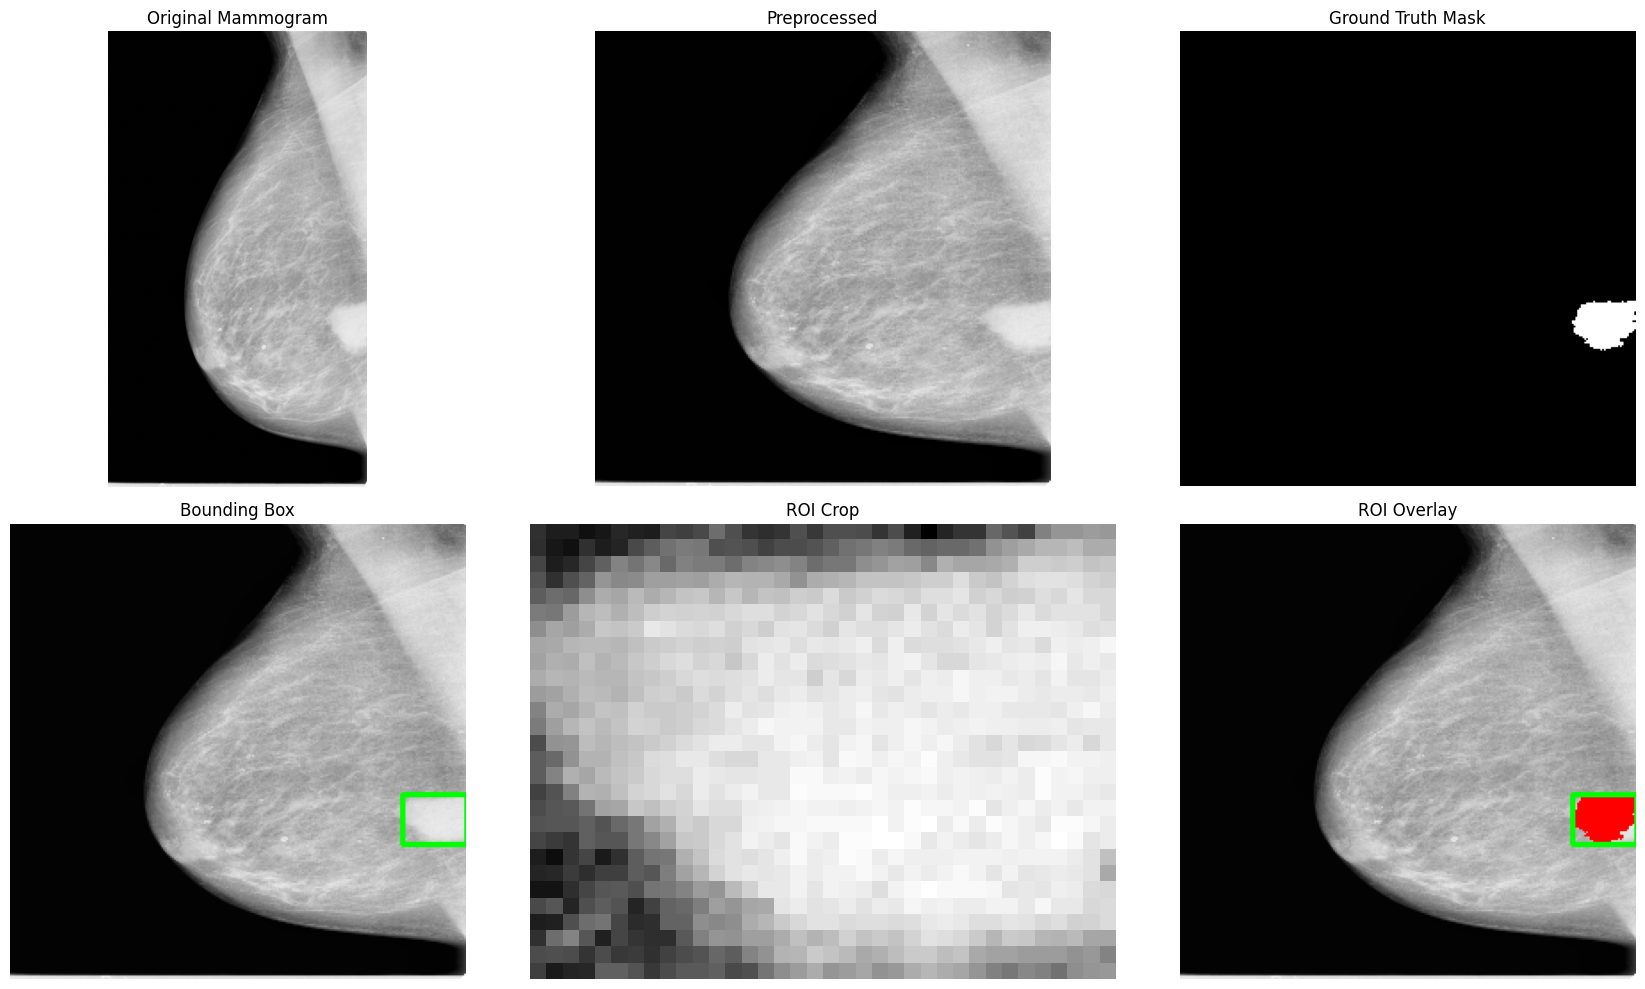

Random Sample Index: 1070


In [48]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Select a random image
idx = random.randint(0, len(pairs)-1)

img_path, mask_path, shape = pairs[idx]
# Original mammogram
original = preprocess_image(img_path, resize=False)
original = (original * 255).astype(np.uint8)

# Preprocessed image and mask
preprocessed = (X[idx].squeeze()*255).astype(np.uint8)
mask = (Y[idx].squeeze()*255).astype(np.uint8)

# Find bounding box
contours, _ = cv2.findContours(mask,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

boxed = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

if len(contours) > 0:

    cnt = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(cnt)

    # Draw bounding box
    cv2.rectangle(boxed, (x,y), (x+w,y+h), (0,255,0), 2)

    # ROI
    roi = preprocessed[y:y+h, x:x+w]

    # Overlay
    overlay = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)
    overlay[mask>0] = [255,0,0]      # lesion in blue
    cv2.rectangle(overlay,(x,y),(x+w,y+h),(0,255,0),2)

else:
    roi = np.zeros((50,50),dtype=np.uint8)
    overlay = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

# Plot
fig, ax = plt.subplots(2,3,figsize=(18,10))

ax[0,0].imshow(original,cmap='gray')
ax[0,0].set_title("Original Mammogram")
ax[0,0].axis("off")

ax[0,1].imshow(preprocessed,cmap='gray')
ax[0,1].set_title("Preprocessed")
ax[0,1].axis("off")

ax[0,2].imshow(mask,cmap='gray')
ax[0,2].set_title("Ground Truth Mask")
ax[0,2].axis("off")

ax[1,0].imshow(boxed)
ax[1,0].set_title("Bounding Box")
ax[1,0].axis("off")

ax[1,1].imshow(roi,cmap='gray')
ax[1,1].set_title("ROI Crop")
ax[1,1].axis("off")

ax[1,2].imshow(overlay)
ax[1,2].set_title("ROI Overlay")
ax[1,2].axis("off")

plt.tight_layout()
plt.show()

print("Random Sample Index:", idx)

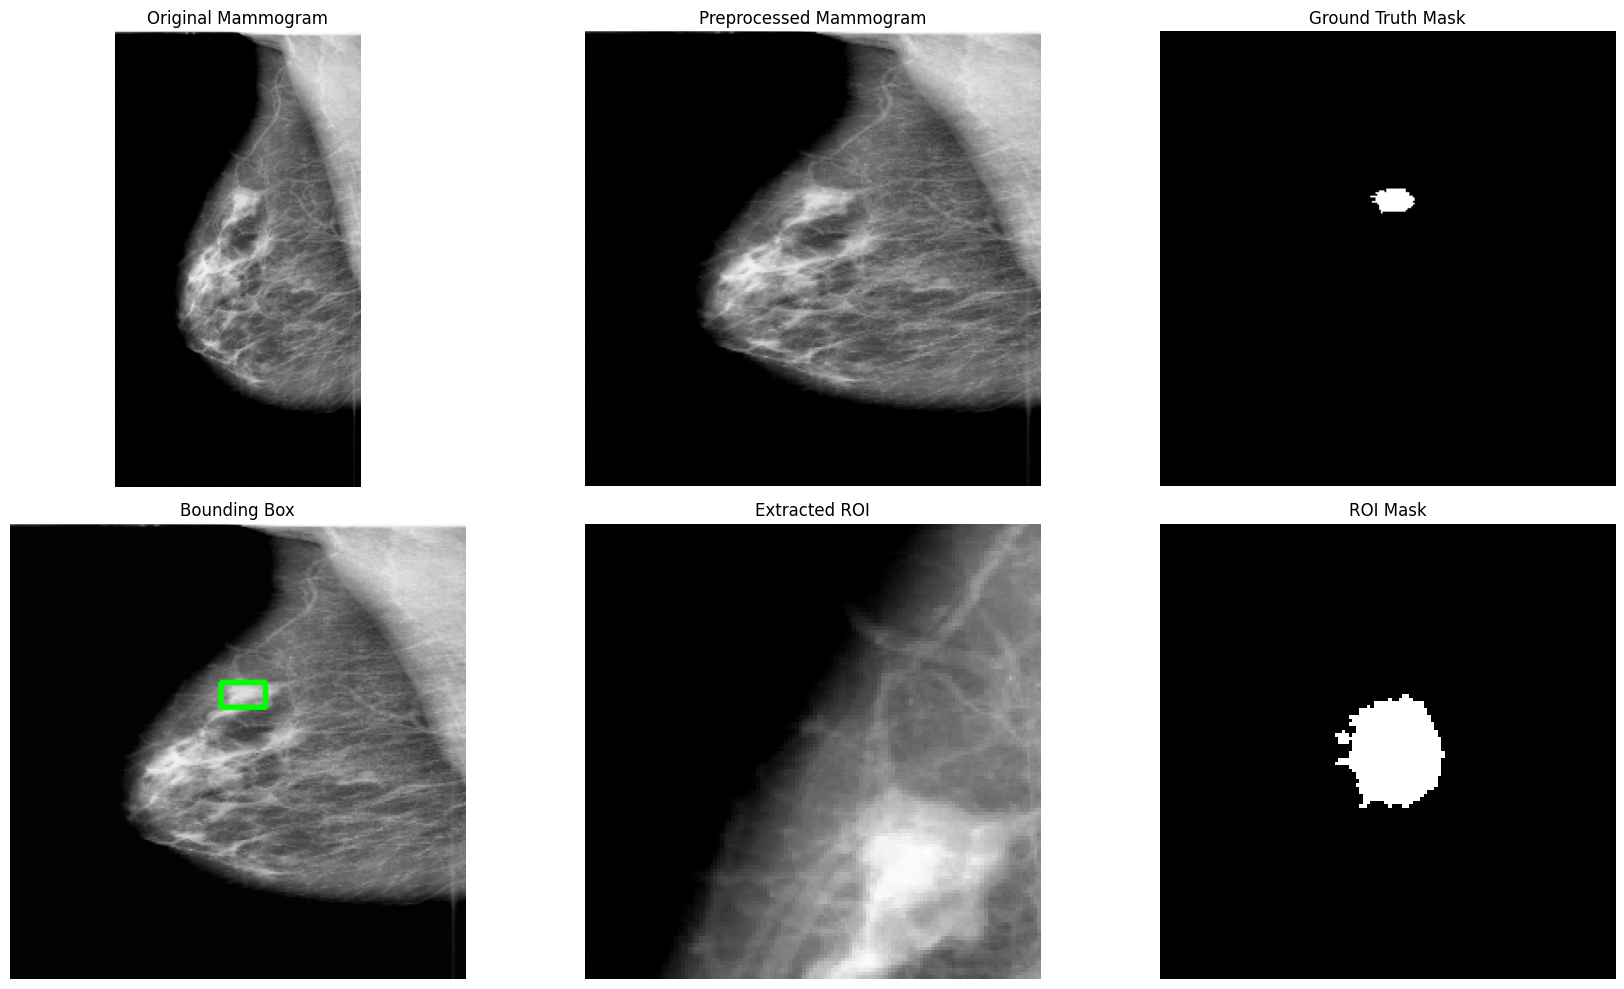

Sample Index : 601
Mass Shape   : IRREGULAR


In [49]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Random sample
idx = random.randint(0, len(ROI_X) - 1)

# Get corresponding original pair index
pair_idx = roi_pair_indices[idx]

img_path, mask_path, shape = pairs[pair_idx]

# Original mammogram (full resolution)
original = preprocess_image(img_path, resize=False)
original = (original * 255).astype(np.uint8)

# Preprocessed mammogram
preprocessed = (X[pair_idx].squeeze() * 255).astype(np.uint8)

# Ground truth mask
mask = (Y[pair_idx].squeeze() * 255).astype(np.uint8)

# ROI image and ROI mask
roi_img = (ROI_X[idx].squeeze() * 255).astype(np.uint8)
roi_mask = (ROI_Y[idx].squeeze() * 255).astype(np.uint8)

# Find bounding box from mask
contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

boxed = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

if len(contours) > 0:

    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)

    cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 255, 0), 2)

else:
    boxed = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

# Plot everything
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0,0].imshow(original, cmap='gray')
ax[0,0].set_title("Original Mammogram")
ax[0,0].axis("off")

ax[0,1].imshow(preprocessed, cmap='gray')
ax[0,1].set_title("Preprocessed Mammogram")
ax[0,1].axis("off")

ax[0,2].imshow(mask, cmap='gray')
ax[0,2].set_title("Ground Truth Mask")
ax[0,2].axis("off")

ax[1,0].imshow(boxed)
ax[1,0].set_title("Bounding Box")
ax[1,0].axis("off")

ax[1,1].imshow(roi_img, cmap='gray')
ax[1,1].set_title("Extracted ROI")
ax[1,1].axis("off")

ax[1,2].imshow(roi_mask, cmap='gray')
ax[1,2].set_title("ROI Mask")
ax[1,2].axis("off")

plt.tight_layout()
plt.show()

print(f"Sample Index : {pair_idx}")
print(f"Mass Shape   : {shape}")